In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import regex as re
import os
import sys
import requests
import time

In [26]:
API_KEY = "26b14325ac8aae8c4e37cce46a3b1b69"

headers = {
    "x-apisports-key": API_KEY
}

In [27]:
url = "https://v3.football.api-sports.io/fixtures"

params = {
    "league": 39,   #premier league
    "season": 2023    
}

response = requests.get(url, headers=headers, params=params)

data = response.json()

In [28]:
print(data.keys())

dict_keys(['get', 'parameters', 'errors', 'results', 'paging', 'response'])


In [42]:
import json
print(json.dumps(data, indent=4))


{
    "get": "fixtures",
    "parameters": {
        "league": "39",
        "season": "2023"
    },
    "errors": {
        "access": "Your account is suspended, check on https://dashboard.api-football.com."
    },
    "results": 0,
    "paging": {
        "current": 1,
        "total": 1
    },
    "response": []
}


In [29]:
matches = data["response"] #Full season

print(len(matches))

0


In [39]:
match_list = []

for match in matches:
    match_info = {
        # Core Info
        "match_id": match["fixture"]["id"],
        "date": match["fixture"]["date"],
        "league_round": match["league"]["round"],
        "referee": match["fixture"]["referee"],
        "venue_name": match["fixture"]["venue"]["name"],
        "venue_city": match["fixture"]["venue"]["city"],

        # teams
        "home_team": match["teams"]["home"]["name"],
        "away_team": match["teams"]["away"]["name"],
        "home_team_id": match["teams"]["home"]["id"],
        "away_team_id": match["teams"]["away"]["id"],

        # scores
        "home_goals": match["goals"]["home"],
        "away_goals": match["goals"]["away"],

        # halftime & fulltime scores
        "halftime_home": match["score"]["halftime"]["home"],
        "halftime_away": match["score"]["halftime"]["away"],
        "fulltime_home": match["score"]["fulltime"]["home"],
        "fulltime_away": match["score"]["fulltime"]["away"],

        # Match Status
        "status": match["fixture"]["status"]["long"]
    }

    match_list.append(match_info)



In [41]:
df_matches = pd.DataFrame(match_list)

print("df_matches created:", df_matches.shape)


df_matches created: (0, 0)


In [ ]:
df_finished = df_matches[df_matches["status"]]

print("Finished matches:", len(df_finished))

In [38]:
print(type(df_matches))


<class 'pandas.DataFrame'>


In [21]:
df_matches.shape
df_matches.head()


NameError: name 'df_matches' is not defined

In [67]:
#functions


def get_match_stats(fixture_id):
    stats_url = "https://v3.football.api-sports.io/fixtures/statistics"
    params = {"fixture": fixture_id}
    response = requests.get(stats_url, headers=headers, params=params)
    return response.json()


def extract_stat(stats_list, stat_name):
    for item in stats_list:
        if item["type"] == stat_name:
            return item["value"]
    return None


def clean_percentage(value):
    if value is None:
        return None
    return float(value.replace("%", ""))





In [30]:

batch1 = df_finished.iloc[0:100]

stats_collection = []

for fixture_id in batch1["match_id"]:
    try:
        stats_data = get_match_stats(fixture_id)

        if not stats_data.get("response"):
            continue

        stats = stats_data["response"]

        if len(stats) < 2:
            continue

        home_stats = stats[0]["statistics"]
        away_stats = stats[1]["statistics"]

        row = {
            "match_id": fixture_id,
            "home_total_shots": extract_stat(home_stats, "Total Shots"),
            "away_total_shots": extract_stat(away_stats, "Total Shots"),
            "home_shots_on_target": extract_stat(home_stats, "Shots on Goal"),
            "away_shots_on_target": extract_stat(away_stats, "Shots on Goal"),
            "home_xg": extract_stat(home_stats, "expected_goals"),
            "away_xg": extract_stat(away_stats, "expected_goals"),
            "home_possession": clean_percentage(
                extract_stat(home_stats, "Ball Possession")
            ),
            "away_possession": clean_percentage(
                extract_stat(away_stats, "Ball Possession")
            )
        }

        stats_collection.append(row)

        time.sleep(3)  # caused rate limit issue

    except Exception as e:
        print("Error:", e)
        continue


NameError: name 'df_finished' is not defined

In [ ]:
df_batch1 = pd.DataFrame(stats_collection)

print("Rows collected in Batch 1:", len(df_batch1))

# we saved to avoid losing our progress
df_batch1.to_csv("stats_batch1.csv", index=False)


Rows collected in Batch 1: 50


In [79]:
df_batch1.head()


,match_id,home_total_shots,away_total_shots,home_shots_on_target,away_shots_on_target,home_xg,away_xg,home_shots_inside_box,away_shots_inside_box,home_shots_outside_box,away_shots_outside_box,home_possession,away_possession
0,1035037,6,17,1,8,0.33,2.08,5,14,1,3,34.0,66.0
1,1035038,15,6,7,2,0.83,1.18,8,4,7,2,78.0,22.0
2,1035039,14,16,5,3,1.37,1.07,5,12,9,4,63.0,37.0
3,1035041,19,9,9,2,2.73,1.50,14,6,5,3,41.0,59.0
4,1035040,27,9,12,3,4.01,1.48,20,7,7,2,71.0,29.0


In [43]:

#LOADING EXISTING POSSESSION

if os.path.exists("possession_master.csv"):
    df_existing = pd.read_csv("possession_master.csv")
    print("Existing possession rows:", len(df_existing))
else:
    df_existing = pd.DataFrame(
        columns=["match_id", "home_possession", "away_possession"]
    )
    print("Starting fresh.")

existing_ids = df_existing["match_id"].tolist()


Existing possession rows: 64


In [44]:

# SELECT MATCHES 65–165

all_finished_ids = df_finished["match_id"].tolist()

remaining_ids = [mid for mid in all_finished_ids if mid not in existing_ids]

print("Remaining matches:", len(remaining_ids))




NameError: name 'df_finished' is not defined

In [45]:
batch3_ids = remaining_ids[:100]

print("Batch 3 size:", len(batch3_ids))

Batch 3 size: 0


In [46]:

#BATCH 3 POSSESSION EXTRACTION

def extract_possession(stats_list):
    for item in stats_list:
        if item["type"] == "Ball Possession":
            return float(item["value"].replace("%", ""))
    return None


batch3_collection = []
request_count = 0

for fixture_id in batch3_ids:
    try:
        response = requests.get(
            "https://v3.football.api-sports.io/fixtures/statistics",
            headers=headers,
            params={"fixture": fixture_id},
            timeout=10
        )

        stats_data = response.json()

        if not stats_data.get("response"):
            print("No response:", fixture_id)
            continue

        stats = stats_data["response"]

        if len(stats) < 2:
            continue

        row = {
            "match_id": fixture_id,
            "home_possession": extract_possession(stats[0]["statistics"]),
            "away_possession": extract_possession(stats[1]["statistics"])
        }

        batch3_collection.append(row)

        request_count += 1
        print("Batch 3 requests used:", request_count)

        time.sleep(10)  # safe rate control

    except Exception as e:
        print("Error:", e)
        continue


In [47]:
# MERGE & SAVE

df_batch3 = pd.DataFrame(batch3_collection)

print("Batch 3 rows collected:", len(df_batch3))

df_updated = pd.concat([df_existing, df_batch3], ignore_index=True)
df_updated.drop_duplicates(subset="match_id", inplace=True)

df_updated.to_csv("possession_master.csv", index=False)

print("Total possession rows after merge:", len(df_updated))


Batch 3 rows collected: 0
Total possession rows after merge: 64


In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid") 
plt.rcParams["figure.figsize"] = (10,6)


In [110]:
#DATASET SECTION
df= pd.read_csv("season-2324.csv")

df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,11/08/23,Burnley,Man City,0,3,A,0,2,A,C Pawson,...,1,8,11,8,6,5,0,0,1,0
1,12/08/23,Arsenal,Nott'm Forest,2,1,H,2,0,H,M Oliver,...,7,2,12,12,8,3,2,2,0,0
2,12/08/23,Bournemouth,West Ham,1,1,D,0,0,D,P Bankes,...,5,3,9,14,10,4,1,4,0,0
3,12/08/23,Brighton,Luton,4,1,H,1,0,H,D Coote,...,12,3,11,12,6,7,2,2,0,0
4,12/08/23,Everton,Fulham,0,1,A,0,0,D,S Attwell,...,9,2,12,6,10,4,0,2,0,0


In [111]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Date      380 non-null    str  
 1   HomeTeam  380 non-null    str  
 2   AwayTeam  380 non-null    str  
 3   FTHG      380 non-null    int64
 4   FTAG      380 non-null    int64
 5   FTR       380 non-null    str  
 6   HTHG      380 non-null    int64
 7   HTAG      380 non-null    int64
 8   HTR       380 non-null    str  
 9   Referee   380 non-null    str  
 10  HS        380 non-null    int64
 11  AS        380 non-null    int64
 12  HST       380 non-null    int64
 13  AST       380 non-null    int64
 14  HF        380 non-null    int64
 15  AF        380 non-null    int64
 16  HC        380 non-null    int64
 17  AC        380 non-null    int64
 18  HY        380 non-null    int64
 19  AY        380 non-null    int64
 20  HR        380 non-null    int64
 21  AR        380 non-null    int64
dtypes: int64(16),

In [112]:
print(df.columns)

Index(['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG',
       'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC',
       'HY', 'AY', 'HR', 'AR'],
      dtype='str')


In [113]:
df = df.rename(columns={
    "FTHG": "home_goals",
    "FTAG": "away_goals",
    "HS": "home_shots",
    "AS": "away_shots",
    "HST": "home_shots_on_target",
    "AST": "away_shots_on_target",
    "HY": "home_yellow",
    "AY": "away_yellow",
    "HR": "home_red",
    "AR": "away_red",
    "FTR": "result"
})


In [142]:
df["home_shot_accuracy"] = (df["home_shots_on_target"] / df["home_shots"]) * 100
df["away_shot_accuracy"] = (df["away_shots_on_target"] / df["away_shots"]) * 100

df["home_conversion"] = df["home_goals"] / df["home_shots"]
df["away_conversion"] = df["away_goals"] / df["away_shots"]

df.fillna(0, inplace=True)


,Date,HomeTeam,AwayTeam,home_goals,away_goals,result,HTHG,HTAG,HTR,Referee,...,AC,home_yellow,away_yellow,home_red,away_red,home_accuracy,away_shot_accuracy,home_conversion,away_conversion,home_shot_accuracy
0,11/08/23,Burnley,Man City,0,3,A,0,2,A,C Pawson,...,5,0,0,1,0,0.166667,47.058824,0.000000,0.176471,16.666667
1,12/08/23,Arsenal,Nott'm Forest,2,1,H,2,0,H,M Oliver,...,3,2,2,0,0,0.466667,33.333333,0.133333,0.166667,46.666667
2,12/08/23,Bournemouth,West Ham,1,1,D,0,0,D,P Bankes,...,4,1,4,0,0,0.357143,18.750000,0.071429,0.062500,35.714286
3,12/08/23,Brighton,Luton,4,1,H,1,0,H,D Coote,...,7,2,2,0,0,0.444444,33.333333,0.148148,0.111111,44.444444
4,12/08/23,Everton,Fulham,0,1,A,0,0,D,S Attwell,...,4,0,2,0,0,0.473684,22.222222,0.000000,0.111111,47.368421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,19/05/24,Crystal Palace,Aston Villa,5,0,H,2,0,H,D Bond,...,4,1,4,0,0,0.600000,25.000000,0.333333,0.000000,60.000000
376,19/05/24,Liverpool,Wolves,2,0,H,2,0,H,C Kavanagh,...,2,1,1,0,1,0.388889,75.000000,0.055556,0.000000,38.888889
377,19/05/24,Luton,Fulham,2,4,A,1,2,A,M Donohue,...,4,5,4,0,0,0.400000,46.666667,0.133333,0.266667,40.000000
378,19/05/24,Man City,West Ham,3,1,H,2,1,H,J Brooks,...,2,0,1,0,0,0.428571,66.666667,0.107143,0.333333,42.857143


In [143]:
home_df = df[[
    "HomeTeam","home_goals","home_shots","home_shot_accuracy",
    "home_conversion","home_yellow","home_red","result"
]].copy()

home_df.columns = [
    "Team","Goals","Shots","Accuracy",
    "Conversion","Yellow","Red","Result"
]

home_df["Points"] = home_df["Result"].map({
    "H":3,"D":1,"A":0
})


In [144]:
away_df = df[[
    "AwayTeam","away_goals","away_shots","away_shot_accuracy",
    "away_conversion","away_yellow","away_red","result"
]].copy()

away_df.columns = [
    "Team","Goals","Shots","Accuracy",
    "Conversion","Yellow","Red","Result"
]

away_df["Points"] = away_df["Result"].map({
    "A":3,"D":1,"H":0
})


In [145]:
team_df = pd.concat([home_df, away_df], ignore_index=True)
team_df.head()


,Team,Goals,Shots,Accuracy,Conversion,Yellow,Red,Result,Points
0,Burnley,0,6,16.666667,0.000000,0,1,A,0
1,Arsenal,2,15,46.666667,0.133333,2,0,H,3
2,Bournemouth,1,14,35.714286,0.071429,1,0,D,1
3,Brighton,4,27,44.444444,0.148148,2,0,H,3
4,Everton,0,19,47.368421,0.000000,0,0,A,0


In [146]:
team_df.shape

(760, 9)

In [147]:
print(df.columns)


Index(['Date', 'HomeTeam', 'AwayTeam', 'home_goals', 'away_goals', 'result',
       'HTHG', 'HTAG', 'HTR', 'Referee', 'home_shots', 'away_shots',
       'home_shots_on_target', 'away_shots_on_target', 'HF', 'AF', 'HC', 'AC',
       'home_yellow', 'away_yellow', 'home_red', 'away_red', 'home_accuracy',
       'away_shot_accuracy', 'home_conversion', 'away_conversion',
       'home_shot_accuracy'],
      dtype='str')


In [148]:
team_summary = team_df.groupby("Team").agg({
    "Goals":"sum",
    "Shots":"sum",
    "Accuracy":"mean",
    "Conversion":"mean",
    "Yellow":"sum",
    "Red":"sum",
    "Points":"sum"
}).reset_index()


In [149]:
team_summary.head()

,Team,Goals,Shots,Accuracy,Conversion,Yellow,Red,Points
0,Arsenal,91,657,34.426856,0.138732,62,2,89
1,Aston Villa,76,514,37.031140,0.144601,94,2,68
2,Bournemouth,54,542,34.088264,0.103656,80,3,48
3,Brentford,56,473,39.419795,0.123454,88,2,39
4,Brighton,55,562,37.050785,0.103884,89,3,48


In [150]:
team_summary = team_summary.sort_values(
    by="Points",ascending=False
).reset_index(drop=True)

team_summary["Position"] = team_summary.index + 1

team_summary.head()


,Team,Goals,Shots,Accuracy,Conversion,Yellow,Red,Points,Position
0,Man City,96,690,43.014918,0.152709,51,2,91,1
1,Arsenal,91,657,34.426856,0.138732,62,2,89,2
2,Liverpool,86,790,35.036890,0.119531,65,5,82,3
3,Aston Villa,76,514,37.031140,0.144601,94,2,68,4
4,Tottenham,74,582,37.793983,0.137725,88,4,66,5


Hypothesis 1 - Shot Accuracy increases probability of winning

In [153]:
h1=team_summary.groupby('Position')['Accuracy'].mean()
print (h1)

Position
1     43.014918
2     34.426856
3     35.036890
4     37.031140
5     37.793983
6     41.616482
7     34.514543
8     39.463162
9     35.514916
10    39.225285
11    37.050785
12    34.088264
13    32.730606
14    39.686422
15    40.608418
16    39.419795
17    33.483049
18    34.673454
19    31.897741
20    33.747008
Name: Accuracy, dtype: float64


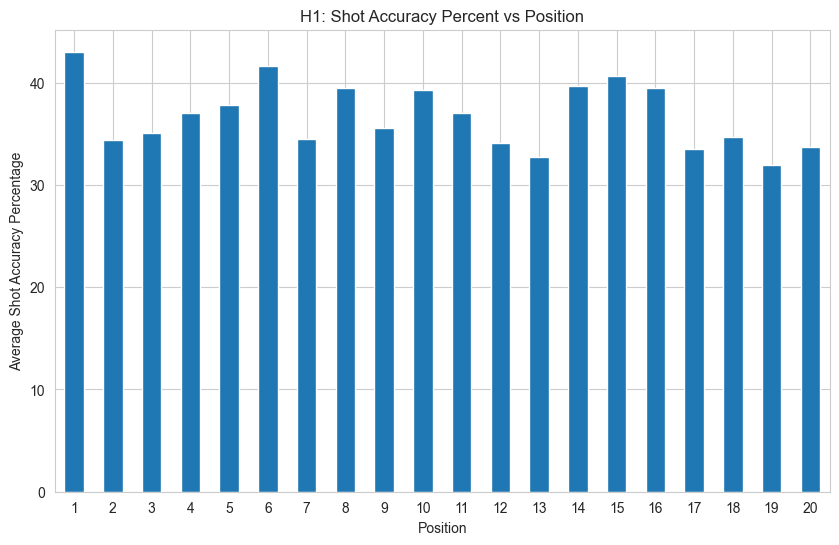

In [155]:
h1.plot(kind='bar')

plt.title("H1: Shot Accuracy Percent vs Position")
plt.ylabel("Average Shot Accuracy Percentage")
plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19], ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20'], rotation=0)

plt.show()

Hypothesis 2- Goal conversion is a stronger predictor of league outcome compared to shot accurarcy

In [165]:
h2=team_summary.groupby('Position')['Goals'].mean()
print(h2)

Position
1     96.0
2     91.0
3     86.0
4     76.0
5     74.0
6     77.0
7     57.0
8     85.0
9     60.0
10    57.0
11    55.0
12    54.0
13    40.0
14    55.0
15    50.0
16    56.0
17    49.0
18    52.0
19    41.0
20    35.0
Name: Goals, dtype: float64


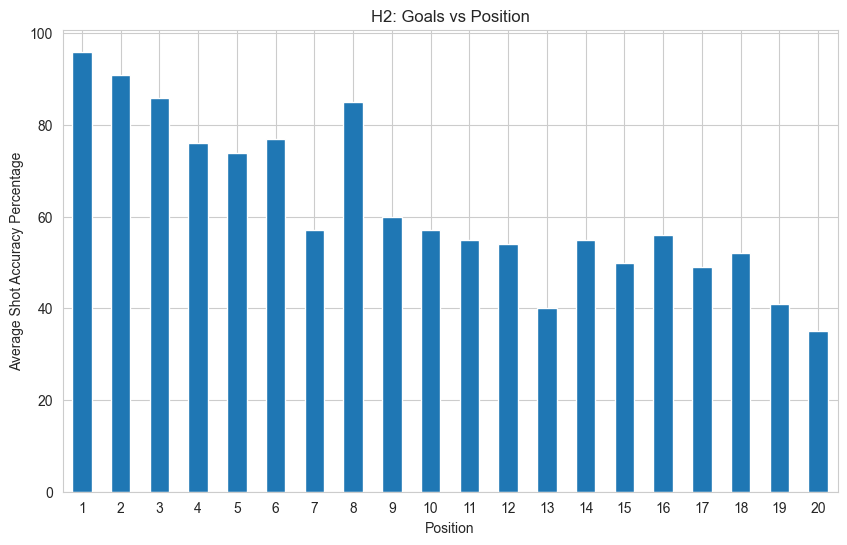

In [166]:
h2.plot(kind='bar')

plt.title("H2: Goals vs Position")
plt.ylabel("Average Shot Accuracy Percentage")
plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19], ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20'], rotation=0)

plt.show()

Hypothesis 3- discipline

In [203]:
team_summary["Discipline_Score"] = \
    team_summary["Yellow"] + (team_summary["Red"]*2)


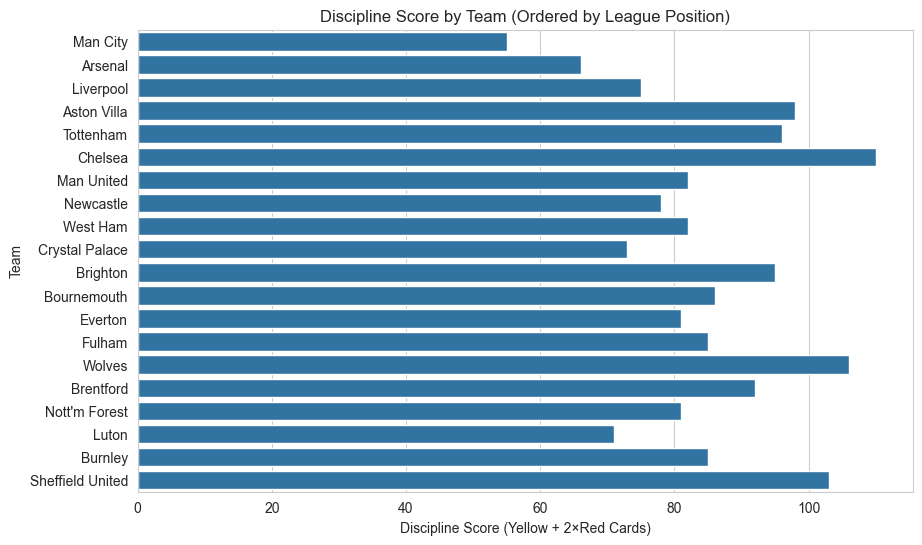

In [204]:
sns.barplot(
    data=team_summary.sort_values("Position"),
    x="Discipline_Score",
    y="Team"
)

plt.title("Discipline Score by Team (Ordered by League Position)")
plt.xlabel("Discipline Score (Yellow + 2×Red Cards)")
plt.ylabel("Team")
plt.show()


Hypotheis 4- Most teams with higher possession of the ball, convert more goals

In [191]:
df_64 = df.head(64)

df_64.head()

,Date,HomeTeam,AwayTeam,home_goals,away_goals,result,HTHG,HTAG,HTR,Referee,...,AC,home_yellow,away_yellow,home_red,away_red,home_accuracy,away_shot_accuracy,home_conversion,away_conversion,home_shot_accuracy
0,11/08/23,Burnley,Man City,0,3,A,0,2,A,C Pawson,...,5,0,0,1,0,0.166667,47.058824,0.000000,0.176471,16.666667
1,12/08/23,Arsenal,Nott'm Forest,2,1,H,2,0,H,M Oliver,...,3,2,2,0,0,0.466667,33.333333,0.133333,0.166667,46.666667
2,12/08/23,Bournemouth,West Ham,1,1,D,0,0,D,P Bankes,...,4,1,4,0,0,0.357143,18.750000,0.071429,0.062500,35.714286
3,12/08/23,Brighton,Luton,4,1,H,1,0,H,D Coote,...,7,2,2,0,0,0.444444,33.333333,0.148148,0.111111,44.444444
4,12/08/23,Everton,Fulham,0,1,A,0,0,D,S Attwell,...,4,0,2,0,0,0.473684,22.222222,0.000000,0.111111,47.368421


In [192]:
possession_df = pd.read_csv("possession_master.csv")

possession_df.columns

Index(['match_id', 'home_total_shots', 'away_total_shots',
       'home_shots_on_target', 'away_shots_on_target', 'home_xg', 'away_xg',
       'home_shots_inside_box', 'away_shots_inside_box',
       'home_shots_outside_box', 'away_shots_outside_box', 'home_possession',
       'away_possession'],
      dtype='str')

In [187]:
possession_df = possession_df.drop(columns=[
    "home_total_shots", "away_total_shots",
    "home_shots_on_target", "away_shots_on_target",
    "home_xg", "away_xg",
    "home_shots_inside_box", "away_shots_inside_box",
    "home_shots_outside_box", "away_shots_outside_box"
])

In [190]:
possession_df.head()

,match_id,home_possession,away_possession
0,1035037,34.0,66.0
1,1035038,78.0,22.0
2,1035039,63.0,37.0
3,1035041,41.0,59.0
4,1035040,71.0,29.0


In [194]:
merged_df = pd.concat([df_64, possession_df], axis=1)

merged_df.head()

,Date,HomeTeam,AwayTeam,home_goals,away_goals,result,HTHG,HTAG,HTR,Referee,...,home_shots_on_target,away_shots_on_target,home_xg,away_xg,home_shots_inside_box,away_shots_inside_box,home_shots_outside_box,away_shots_outside_box,home_possession,away_possession
0,11/08/23,Burnley,Man City,0,3,A,0,2,A,C Pawson,...,1.0,8.0,0.33,2.08,5.0,14.0,1.0,3.0,34.0,66.0
1,12/08/23,Arsenal,Nott'm Forest,2,1,H,2,0,H,M Oliver,...,7.0,2.0,0.83,1.18,8.0,4.0,7.0,2.0,78.0,22.0
2,12/08/23,Bournemouth,West Ham,1,1,D,0,0,D,P Bankes,...,5.0,3.0,1.37,1.07,5.0,12.0,9.0,4.0,63.0,37.0
3,12/08/23,Brighton,Luton,4,1,H,1,0,H,D Coote,...,9.0,2.0,2.73,1.50,14.0,6.0,5.0,3.0,41.0,59.0
4,12/08/23,Everton,Fulham,0,1,A,0,0,D,S Attwell,...,12.0,3.0,4.01,1.48,20.0,7.0,7.0,2.0,71.0,29.0


In [195]:
merged_df.columns

Index(['Date', 'HomeTeam', 'AwayTeam', 'home_goals', 'away_goals', 'result',
       'HTHG', 'HTAG', 'HTR', 'Referee', 'home_shots', 'away_shots',
       'home_shots_on_target', 'away_shots_on_target', 'HF', 'AF', 'HC', 'AC',
       'home_yellow', 'away_yellow', 'home_red', 'away_red', 'home_accuracy',
       'away_shot_accuracy', 'home_conversion', 'away_conversion',
       'home_shot_accuracy', 'match_id', 'home_total_shots',
       'away_total_shots', 'home_shots_on_target', 'away_shots_on_target',
       'home_xg', 'away_xg', 'home_shots_inside_box', 'away_shots_inside_box',
       'home_shots_outside_box', 'away_shots_outside_box', 'home_possession',
       'away_possession'],
      dtype='str')

In [ ]:
h3=merged_df.groupby(['HomeTeam', 'AwayTeam'])['home_possession'].mean()

(64,)